<center><img src="https://i.imgur.com/YNtjmbq.png" width="800"></center> 

<a target="_blank" href="https://colab.research.google.com/github/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/blob/main/sesion_2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# EXPLORACION DE REDES Y SUS COMPONENTES


<div class="alert alert-info" role="alert">
    
**Data para la sesión**

Para esta sesión, los datos puedes descargarlos en _tu_ carpeta **data** desde este [enlace](https://drive.google.com/drive/folders/1xri-lWtXZv-7Ce5_xJ31GQFVnJZJ1zeo?usp=sharing).
</div>



En el año 2018, Quinten Dol sugirió a los usuarios de Twitter seguir a estas celebridades de la Tecnologia local:


<a href="https://www.builtinseattle.com/articles/50-seattle-tech-twitter-accounts-to-follow" target="_blank">
    <img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/influentialTweet.jpg
" alt="Influential Tweet" style="max-width: 100%; height: auto;">
</a>

Aunque proponía 50 _influencers_, sólo hay 46 activos en X (antes Twitter). Se construyó una red para ver si entre ellos se seguían, y [esto tenemos](https://docs.google.com/spreadsheets/u/1/d/e/2PACX-1vQaaNQb2frjnlt0fPSBQhp5tNydB0a9ibp98sblBn6OfvGd8vsx8cfHb4w8Cm_qC3EIeYFby_zNQBoK/pubhtml):

In [3]:
from IPython.display import IFrame
IFrame('https://docs.google.com/spreadsheets/d/e/2PACX-1vQvzPtFqK2pgq8xGLZy4EsGyT0RU-3ghuqhJOmEm8J0YEZ1SOjXn1aLGZmKIUmTGRr-ww1jdULhAPvz/pubhtml', 800, 350)

## Creando la red

Como ya sabemos, la red se arma con la **adjacency matrix** o la **edgelist**. Hagámoslo nuevamente:

In [4]:
# librerias necesarias
import networkx as nx
import pandas as pd

# link a GoogleDrive como un Excel
linkGoogle="https://docs.google.com/spreadsheets/d/e/2PACX-1vQvzPtFqK2pgq8xGLZy4EsGyT0RU-3ghuqhJOmEm8J0YEZ1SOjXn1aLGZmKIUmTGRr-ww1jdULhAPvz/pub?output=xlsx"

# leyendo archivo de red
adjacency=pd.read_excel(linkGoogle,   
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='adjacency') # la tabla tiene este nombre



Los grafos de las tredes sociales como `Twitter` / `X` son generalmente **dirigidos** pues un nodo sigue a otro, pero la relación no es necesariamente recíproca. 

In [5]:
# creando red dirigida
TopFromAdjacency=nx.from_pandas_adjacency(adjacency,create_using=nx.DiGraph)
# info de lo que tenemos
print(TopFromAdjacency)

DiGraph with 46 nodes and 588 edges


El objeto **TopFromAdjacency** contiene a la `red dirigida`.

¿Tendremos algun _influencer_ que no siga a otro ni sea seguido por otro?

In [6]:
list(nx.isolates(TopFromAdjacency))

[]

De ahi que la red no mostrará nodos aislados:

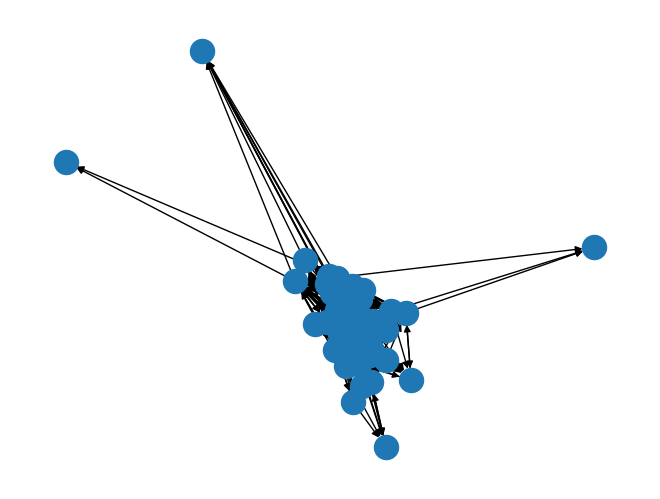

In [7]:
nx.draw(TopFromAdjacency)

## Añadiendo atributos

Notese que tenemos atributos para la red:

In [8]:
atributos=pd.read_excel(linkGoogle,   
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='attributes') # la tabla tiene este nombre

# nota que la columna 1 la abrí como el nombre de fila (index)
atributos

,male,followers
Id,,
rachelerman,0,7139
mattmcilwain,1,2804
DaveParkerSEA,1,3328
toddbishop,1,24500
ashannstew,0,3382
LeslieFeinzaig,0,15900
akipman,1,29500
matt_oppy,1,4847
gilbert,1,25800


Los atributos de cada nodo deben ser parte de la red dirigida actual. El proceso es simple:

In [9]:
# Convertimos el DataFrame en un diccionario indexado por el nodo
atributos_nodos = atributos.to_dict('index')

# Pasamos todos los atributos al grafo de un solo golpe
nx.set_node_attributes(TopFromAdjacency, atributos_nodos)

Podemos verificarlo asi:

In [10]:
TopFromAdjacency.nodes(data=True)

NodeDataView({'rachelerman': {'male': 0, 'followers': 7139}, 'mattmcilwain': {'male': 1, 'followers': 2804}, 'DaveParkerSEA': {'male': 1, 'followers': 3328}, 'toddbishop': {'male': 1, 'followers': 24500}, 'ashannstew': {'male': 0, 'followers': 3382}, 'LeslieFeinzaig': {'male': 0, 'followers': 15900}, 'akipman': {'male': 1, 'followers': 29500}, 'matt_oppy': {'male': 1, 'followers': 4847}, 'gilbert': {'male': 1, 'followers': 25800}, 'juliesandler': {'male': 0, 'followers': 7031}, 'BradSmi': {'male': 1, 'followers': 96300}, 'crashdev': {'male': 0, 'followers': 8773}, 'ShaunaCausey': {'male': 0, 'followers': 47400}, 'john_gabbert': {'male': 1, 'followers': 2482}, 'moniguzman': {'male': 0, 'followers': 29000}, 'mattmday': {'male': 1, 'followers': 5750}, 'Rich_Barton': {'male': 1, 'followers': 31300}, 'daryn': {'male': 1, 'followers': 2378}, 'lovelletters': {'male': 0, 'followers': 4553}, 'etzioni': {'male': 1, 'followers': 27400}, 'MissDestructo': {'male': 0, 'followers': 41800}, 'heatherre

Ya con esto, podemos exportarlo:

In [11]:
filename1='seattle.gml' # nombre incluye 'donde'
filename2='seattle.graphml'

# guardando:
nx.write_gml(TopFromAdjacency,filename1)

nx.write_graphml(TopFromAdjacency,filename2)

<div class="alert alert-warning" role="alert">
    
**Usa GEPHI y abre la red de los tech influencers de Seattle.**

</div>

Gephi abre los archivos `gml` o `graphml` directamente. Pero si no quieres pasar por Python y usar el Excel directamente, requiere dos pasos:
1. Importar la matriz desde excel (visto enla primera sesión)
2. Importar y combinar los atributos desde Excel.

 El segundo paso lo detallo a continuación:

La importación usa la misma opción del menú: `importar hoja de calculo` (como lo usaste con la matriz), pero esta vez hay otras opciones a elegir:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/importAttr1.jpg"/>


En el siguiente paso, elije el tipo respectivo de datos para cada columna, por ejemplo:
<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/importAttr2.jpg"/>


Por lo general, podemos explorar la red de dos maneras:

1. A nivel de red en total.
2. A nivel de cada actor (nodo).

# 1. Explorando a nivel de red

A continuación, se detallan las métricas fundamentales para comprender la red como una entidad completa.

## Conectividad

Una de las primeras interrogantes, es saber si cada nodo puede conectarse con otro nodo. Para que ello sucede, teniendo en cuenta que la red es dirigida, debe haber un **path** o camino (sequencia de flechas) entre todo par de nodos de la red. Si esto fuera así, se debe verificar que la red es **strongly_connected**.

En la Figura 1 vemos una red que tiene componentes fuertemente conectados, pero la red en su totalidad no lo es:
<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/strongly_connected.png" style="width:70%">
<figcaption align = "center"> Figura 1. Red y componentes fuertemente conectados </figcaption>
    <a href="https://en.wikipedia.org/wiki/Strongly_connected_component" class="alert-link">Fuente:Wikipedia</a>
</figure>


Nuestra red tampoco lo es:

In [31]:
nx.is_strongly_connected(TopFromAdjacency)

False

## Distancia y el Geodésico

La **distance** se entiende como la cantidad de _edges_ que separan un par de nodos. Como entre algun par de nodos puede haber muchas distancias, llamamos **geodésico** a la distancia más corta entre dos nodos. La Figura 2 nos muestra algunos geodésicos:

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/geodesics.png" style="width:70%">
<figcaption align = "center"> Figura 2. Geodésicos. 
 </figcaption>
 <a href="https://www.wolframphysics.org/technical-introduction/limiting-behavior-and-emergent-geometry/geodesics/" class="alert-link">Fuente: Wolframphysics</a>
</figure>

Revisemos los conceptos de **diámetro** y **distancia media**.

### a. Diámetro

Una métrica clave  que podemos calcular de la matriz de geodésicos es el **diámetro**. El diámetro es el máximo de los geodésico, pues representa la distancia mas corta entre las celdas mas alejadas de la red. Veámoslo en la Figura 3.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/diameter.png" style="width:70%">
<figcaption align = "center"> Figura 3. Diámetro. 
 </figcaption>
 Fuente: Autor.
</figure>


La función **diameter()** no podemos calcularlo de una red que no se fuertemente conectada. Pero tratemos dos opciones informativas:

In [32]:
# Convertir a no dirigido y calcular el diámetro de la estructura general
diametro_no_dirigido = nx.diameter(TopFromAdjacency.to_undirected())
print(f"Diámetro de la red (Estructura Social no dirigida): {diametro_no_dirigido}")

Diámetro de la red (Estructura Social no dirigida): 3


In [33]:
# 1. Extraer los componentes fuertemente conectados ordenados por tamaño
componentes_fuertes = sorted(nx.strongly_connected_components(TopFromAdjacency), key=len, reverse=True)

# 2. Aislar el subgrafo del componente más grande (el gigante)
componente_gigante = TopFromAdjacency.subgraph(componentes_fuertes[0])

# 3. Calcular el diámetro real de ese núcleo cooperativo
diametro_efectivo = nx.diameter(componente_gigante)
print(f"Diámetro del Componente Fuertemente Conectado Gigante: {diametro_efectivo}")

Diámetro del Componente Fuertemente Conectado Gigante: 4


El diámetro define **el peor escenario posible** (la distancia geodésica más larga) dentro de esta red de 46 líderes tecnológicos. Es la medida exacta de la extensión máxima del tejido social.

> **Diámetro No Dirigido**: Un diámetro de 3 significa que, incluso los dos líderes más alejados entre sí en este ecosistema, están a un máximo de **dos intermediarios** de distancia, algo como (Líder A $\rightarrow$ Líder B $\rightarrow$ Líder C $\rightarrow$ Líder D). Si este es el peor caso, solemos decir qué pequeño es el mundo, y en este campo se le denomina una red tipo `small-world`: nadie en este grupo de 46 personas es un extraño total; todos están integrados en una estructura compacta donde la información técnica no tiene que viajar largas jornadas para cubrir a todo el grupo.

> **Diámetro del Componente Fuertemente Conectado Gigante (GSCC**): Representa un cálculo metodológicamente más riguroso porque respeta la dirección de las flechas (quién sigue a quién) y se enfoca en el núcleo de la red donde existe un camino orientado (directo o indirecto) de ida y vuelta entre cualquier par de nodos. El hecho de que el diámetro aumente a solo 4 pasos al considerar la direccionalidad es un indicador de altísima eficiencia. Significa que el flujo de información es casi tan rápido siguiendo las reglas estrictas de Twitter como si la red fuera totalmente simétrica. Un diámetro dirigido de apenas 4 pasos en este componente gigante garantiza que el intercambio de conocimiento y recursos entre los líderes es fluido, constante y predecible. La red esquiva el riesgo de generar caminos excesivamente largos o laberínticos para conectar a sus miembros orientados.

Anclando estos resultados, se derivan tres conclusiones estructurales sobre el ecosistema:

* **Difusión Masiva:** Las redes sociales en Internet permiten una difusión que marca una gran diferencia por su alcance. Con un diámetro de entre 3 y 4 pasos, esta red opera como un **conducto de información óptimo**. Una innovación lanzada en un extremo del grafo saturará a todo el grupo de líderes en un tiempo récord.
* **Persuasión y Marketing Viral:** En estructuras con estas características morfológicas, la literatura especializada coincide en que *persuadir es un proceso sumamente ágil*. La corta distancia entre los puntos más extremos del tejido facilita que las ideas se compartan rápidamente, acelerando la convergencia cultural y la adopción de tendencias entre todos los miembros.
* **Resiliencia Sistémica:** Al mantener un diámetro tan pequeño, la red no solo es veloz, sino también **altamente robusta**. La comunicación no depende de cadenas de transmisión largas y frágiles que puedan interrumpirse con facilidad, sino que se apoya en una infraestructura de nexos inherentemente cortos y directos.


### b. Accesibilidad (Distancia Media)

Representa el número promedio de nexos o pasos necesarios para conectar a dos individuos cualesquiera en la red. Describe a la red como un **conducto** por donde fluyen ideas o recursos.


In [12]:
if nx.is_weakly_connected(TopFromAdjacency):
    distancia_media = nx.average_shortest_path_length(TopFromAdjacency.to_undirected())

    #aqui
distancia_media

1.633816425120773

La distancia media de 1.63 pasos es un valor notablemente bajo que indica una proximidad excepcional dentro de esta red de 46 líderes tecnológicos. Evaluada sobre el componente conexo de interacciones base (red no dirigida) —una simplificación necesaria dado que el grafo global orientado no es fuertemente conectado—, esta cifra revela una estructura social con las siguientes características:

* **Eficiencia del "Conducto":** Las teorías de redes definen los lazos como conductos por donde fluyen ideas y recursos. Una distancia de 1.63 significa que, en promedio, `cualquier líder puede alcanzar a otro en menos de dos saltos sociales`. Esto garantiza que la información circule con una rapidez y fluidez masiva, permitiendo que las innovaciones se difundan de forma casi instantánea.
* **Facilidad para la Difusión Viral:** Debido a que los actores están tan cerca unos de otros, la red posee un potencial altísimo para la persuasión y el contagio social. En estructuras con nexos tan cortos, los fenómenos virales funcionan con mucha facilidad, ya que la información no tiene que atravesar largas cadenas de intermediarios para cubrir a todo el grupo.
* **Alta Cohesión Estructural:** Este valor de proximidad promedio es un indicador de cohesión superior al de una red inter-organizativa típica (como las redes de alianzas estratégicas empresariales, donde las distancias suelen ser mayores). Un valor de 1.63 sugiere que este ecosistema de Twitter actúa como una "comunidad de práctica" compacta donde casi todos los líderes son, como mínimo, "amigos de sus amigos".
* **Autonomía y Capital Social:** Desde una perspectiva estructural, distancias promedio tan cortas significan que los líderes tienen una posición privilegiada para acceder a recursos y noticias de todo el ecosistema sin depender excesivamente de intermediarios o "porteros" (*gatekeepers*) que filtren de más la información.
* **Retroalimentación Estructura-Comportamiento:** El comportamiento de seguimiento en Twitter ha moldeado una morfología donde la distancia es mínima, lo que a su vez refuerza un comportamiento de comunicación interactiva, dinámica y horizontal, típica de las redes de nicho en internet.

> Así, una distancia de 1.63 convierte a esta red en un mapa de información altamente eficiente, donde el conocimiento técnico y las tendencias del ecosistema local están a menos de dos pasos de distancia para la gran mayoría de sus integrantes.

## Densidad

Es la medida del número de vínculos existentes en relación con el número total de vínculos posibles. Es _un_ indicador clave de la **cohesión estructural** de la red.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/density.png" style="width:70%">
<figcaption align = "center"> Figura 4. Densidades en las redes. 
 </figcaption>
 <a href="https://medium.com/@jane.vdplas/https-medium-com-protium-digital-what-are-network-effects-4f1ec159b6">Fuente: Medium</a>
</figure>



In [12]:
# Densidad global
densidad = nx.density(TopFromAdjacency)
densidad

0.28405797101449276

La densidad de **0.2841 (28.41%)** en nuestra red de 46 líderes tecnológicos indica una conectividad **sólida y significativa** para el intercambio de información en un entorno digital como Twitter.

* **Cohesión Estructural:** Este valor significa que de todos los vínculos potenciales en la red, se ha materializado el $28.41\%$ de ellos. Para un ecosistema dirigido, de nicho y acotado a 46 actores, es un porcentaje notable que supera con creces los niveles de dispersión habituales en redes sociales abiertas.
* **La Red como Conducto:** Dado que se trata de líderes tecnológicos que eligen seguirse entre sí, una densidad cercana al $30\%$ determina que la red funciona como un conducto altamente optimizado para la difusión de ideas e innovación. Este volumen de conexiones es el tejido que explica físicamente por qué la distancia promedio de la red es tan corta (1.63 pasos); existen suficientes autopistas directas para que las nuevas tendencias y opiniones se propaguen y ganen visibilidad casi de inmediato.
* **Nivel de Interacción y Atención:** En el análisis de redes sociodigitales, una densidad superior al $20\%$ en entornos de afinidad profesional se considera muy adecuada para el flujo constante de información. En este caso, indica una atención activa hacia el contenido de los pares, consolidando una vitrina común que favorece el *networking*, el debate técnico y el reconocimiento mutuo.

> En resumen, la red muestra una estructura cohesiva robusta donde los canales de comunicación potencial están densamente distribuidos, permitiendo que casi un tercio de todas las trayectorias directas posibles estén construidas. Esto es un indicador saludable de un ecosistema de liderazgo tecnológico local integrado, vigilante y atento a las narrativas de sus propios miembros.

## Alcanzabilidad

La _Alcanzabilidad_ o **Reachability** se define como la existencia de una trayectoria orientada (un camino que respeta la dirección de las flechas) entre un nodo emisor $i$ y un nodo receptor $j$.

Mientras que la **Densidad** mide cuántos lazos directos existen en la red, la **Alcanzabilidad Global** calcula el porcentaje de pares de actores que pueden comunicarse entre sí, ya sea de forma directa o a través de intermediarios (caminos de longitud $k > 1$).

In [24]:
# calculo rápido
cierre = nx.transitive_closure(TopFromAdjacency, reflexive=None)
densidad_alcanzabilidad = nx.density(cierre)
print(f"Porcentaje de Alcanzabilidad de la red: {densidad_alcanzabilidad * 100:.2f}%")

Porcentaje de Alcanzabilidad de la red: 93.48%


In [29]:
# mas ituitivo
# Contamos cuántos pares ordenados sí tienen un camino entre ellos
caminos_existentes = sum(1 for u, v in nx.all_pairs_shortest_path_length(TopFromAdjacency) for target in v if u != target)
nNodes=TopFromAdjacency.number_of_nodes()


# Dividimos entre el total de pares posibles
print("Alcanzabilidad:", caminos_existentes / ((nNodes*(nNodes-1))))

Alcanzabilidad: 0.9347826086956522


El resultado nis deja entender:

* **Casi todos conectados:** Este porcentaje determina que de todas las combinaciones posibles de "Emisor $\rightarrow$ Receptor" en el grafo ($46 \times 45 = 2070$ trayectorias), en el **93.48%** de los casos es matemáticamente viable que la información viaje desde el nodo origen hasta el nodo destino.
* **Explicación del 6.52% Restante:** Al inicio del análisis determinamos que la red general *no es fuertemente conectada*. Este residuo del $6.52\%$ es la explicación matemática de ese fenómeno. No se debe a que la red esté fragmentada en grandes grupos aislados, sino a la presencia de asimetrías en la periferia (como nodos "sumidero" que solo escuchan pero no transmiten, o nodos "fuente" que emiten pero no reciben de la muestra).
* **Sustento del "Mundo Pequeño":** La alcanzabilidad le da sentido físico a la **distancia media de 1.63 pasos** y a los **diámetros de 3 y 4**. Lo que este $93.48\%$ demuestra es que la extrema cercanía promedio de la red no es un espejismo de un grupo pequeño; es una propiedad sistémica que cobija a la práctica totalidad de los líderes del ecosistema.

>  Esta red, en términos prácticos, garantiza que cualquier idea, debate técnico o convocatoria lanzado por la inmensa mayoría de estos líderes tecnológicos tiene garantizada una ruta de navegación limpia y directa para impactar al resto del ecosistema local, blindando la efectividad de la red como una comunidad de aprendizaje unificada.



Densidad y Alcanzabilidad no son sinónimos, veamos la figura 

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/reachability-and-density.png" style="width:70%">
<figcaption align = "center"> Figura 5. Reachability versus Density. 
 </figcaption>
 <a href="https://www.researchgate.net/publication/42763973_Toward_a_Network_Perspective_of_the_Study_of_Resilience_in_Social-Ecological_Systems">Fuente: Ecology and Society</a>
</figure>

Nuetra red está en una fase **policéntrica y óptima**:

* **Alta integración (93.48%):** Mantiene la ventaja del modelo estrella, garantizando que la información se propague y llegue prácticamente a todo el grupo.
* **Salida de la centralización (28.41%):** Al tener casi un tercio de las conexiones posibles materializadas, la red ya superó la vulnerabilidad de depender de un solo líder. El flujo de información se ha democratizado y distribuido entre varios actores, logrando una alta eficiencia sin llegar a la saturación de enlaces.

## Reciprocidad

Mide la proporción de vínculos que implican interacciones mutuas sobre el total de vínculos. Es _fundamental_ en redes dirigidas para evaluar la **coordinación interna** y la estabilidad de la red.


In [11]:
reciprocidad = nx.reciprocity(TopFromAdjacency)
reciprocidad

0.6632653061224489

Este valor es notablemente alto, confirmando una estructura social equilibrada, sólidamente integrada y estable.

* **Definición y Alcance:** La reciprocidad mide la proporción de vínculos dirigidos que son mutuos (bidireccionales). En este contexto, determina que en aproximadamente 2 de cada 3 relaciones de seguimiento en Twitter, la atención es correspondida y el actor receptor devuelve el *follow*.
* **Coordinación y Reconocimiento Mutuo:** Este $66.33\%$ refleja que las conexiones no son unilaterales ni meras dinámicas de aspiración. Existe una fuerte norma implícita de reconocimiento mutuo, validación y respeto intelectual entre los líderes que componen el ecosistema.
* **Indicador de Cohesión Horizontal:** La reciprocidad es uno de los pilares fundamentales de la cohesión estructural. Un nivel tan elevado demuestra que la red ha dejado atrás el esquema de un canal de difusión jerárquico tradicional (donde unos pocos emiten y el resto solo escucha). En su lugar, consolida un espacio donde la comunicación es bidireccional, fortaleciendo el capital social, la reciprocidad generalizada y la confianza.
* **Naturaleza Dinámica de los Nexos:** Este resultado revela que la naturaleza de los nexos tiende fuertemente a la simetría relacional. En términos de flujos informativos, la alta reciprocidad actúa como un circuito de retroalimentación constante: las ideas, innovaciones y debates no solo se propagan en una dirección, sino que se discuten, refutan y validan activamente entre pares.

>  Una reciprocidad del **66.33%** posiciona a esta red como un entorno altamente colaborativo, horizontal y coordinado. Los líderes tecnológicos locales no solo coexisten en el mismo espacio digital, sino que se prestan atención mutua de forma activa, transformando un canal de microblogging en una infraestructura de gobernanza comunitaria.

### Centralización de la Red

Permite comparar en qué magnitud la red se organiza alrededor de un punto o zona central. Indica el grado de jerarquía y restricción a la comunicación global.

In [13]:
# Solución definitiva en Python sin librerías externas inestables
N = TopFromAdjacency.order()
indegrees = dict(TopFromAdjacency.in_degree()).values()
max_in = max(indegrees)

# Fórmula de Freeman para Centralización de Grado de Entrada
centralizacion = (N * max_in - sum(indegrees)) / (N - 1)**2

print("Tu índice de centralización macro es:", centralizacion)

Tu índice de centralización macro es: 0.4138271604938272


**¿Qué significa este resultado?**

> En la teoría de redes, un valor de 0% representa una red absolutamente horizontal (todos los actores tienen exactamente el mismo número de seguidores), mientras que un 100% representa una red en estrella perfecta (un solo líder acumula todos los lazos y los demás cero).

Un índice de 41.38% nos indica una estructura con una centralización moderada-alta. Esto significa que el ecosistema de líderes tecnológicos no es una comunidad anárquica ni puramente distribuida; existe un núcleo claro de figuras dominantes (hiper-influencers) que concentran una gran porción de la atención y actúan como los principales faros de información.

Sin embargo, el hecho de que no supere el 50% confirma que este liderazgo no es un monopolio absoluto. Aunque hay figuras estrella, la periferia de la red retiene suficiente autonomía y conexiones propias, impidiendo que el flujo de comunicación dependa de un único dictador de opinión.

-----

### Agrupamiento (Clustering)

Es un índice que señala el nivel de formación de regiones densas o conglomerados en la red. Un coeficiente alto indica que los actores están muy relacionados con sus vecinos inmediatos ("los amigos de mis amigos son mis amigos").


In [15]:
agrupamiento = nx.average_clustering(TopFromAdjacency)
agrupamiento


0.5705280020639293

Un valor de agrupamiento promedio de **0.5705 (57.05%)** es un indicador elevado y sumamente significativo para una red de 46 líderes tecnológicos, describiendo una estructura social con una fuerte propensión a la formación de burbujas o comunidades locales cerradas.

> * **El efecto "Los amigos de mi amigo son mis amigos":** Este coeficiente mide el nivel de cierre triádico en la red. En este contexto, significa que existe una probabilidad del 57.05% de que si un líder tecnológico sigue a otros dos miembros de la red, esos dos miembros también se sigan entre sí. Demuestra que la red no es una estructura dispersa, sino un tejido compuesto por vecindarios densos.

> * **Formación de Clústeres de Especialización:** Este nivel de agrupamiento sugiere la presencia de subgrupos altamente cohesionados. En un ecosistema de innovación, esto representa comunidades de práctica o de aprendizaje especializadas (por ejemplo, nichos de desarrolladores, inversores o emprendedores) que mantienen vínculos de comunicación muy estrechos entre ellos.

> * **Facilidad para la Persuasión y Difusión de Conocimiento:** Un agrupamiento alto genera un entorno de homofilia y confianza local. La información y las nuevas metodologías se refuerzan constantemente dentro de los subgrupos, lo que valida rápidamente el conocimiento y facilita la adopción de innovaciones compartidas.

> * **Implicaciones para la Innovación Abierta:** Aunque este alto agrupamiento favorece el apoyo interno y la colaboración coordinada, también plantea el reto de evitar el hermetismo. Para el éxito a largo plazo del ecosistema, es vital que estos "racimos" locales sigan intercambiando información a través de los puentes globales de la red para evitar el estancamiento de ideas.

**La Red como un "Mundo Pequeño" (Small World):** Al conectar este dato con la distancia geodésica media (**1.63 pasos**), se puede concluir formalmente que la red posee una estructura de *Mundo Pequeño*. A nivel local, los líderes están fuertemente agrupados en comunidades de confianza (0.5705), pero a nivel global, el tejido está tan bien integrado que cualquier líder puede acceder a otro en menos de dos saltos.

----


### Modularidad 

La modularidad mide la fuerza de la división de una red en módulos, grupos o comunidades. Permite identificar **cliques** (conjuntos máximamente conectados) u otros subgrupos de cohesión.


In [16]:
from networkx.algorithms import community

comunidades = list(community.greedy_modularity_communities(TopFromAdjacency.to_undirected()))
mod_value = community.modularity(TopFromAdjacency.to_undirected(), comunidades)

print(f"Número de comunidades: {len(comunidades)}")
print(f"Índice de Modularidad: {mod_value:.4f}")

Número de comunidades: 4
Índice de Modularidad: 0.1131


La interpretación de estos resultados, en el contexto de la red de 46 líderes tecnológicos, revela una estructura con subgrupos identificables pero altamente integrados a nivel global.

**1. Número de Comunidades Detectadas (4):** Este dato indica que, mediante el análisis de clase de modularidad, se han identificado 4 subgrupos o clústeres principales dentro de los 46 líderes.

> * *Significado social:* En un ecosistema tecnológico, estas 4 comunidades podrían representar diferentes sectores de interés o especialidades (por ejemplo: desarrolladores de software, inversores de capital de riesgo, emprendedores y tecnólogos del sector público).
> * *Organigrama informal:* Esta división permite mapear el "organigrama informal" de la red en la ciudad, identificando grupos que comparten intereses, semánticas o prácticas comunes.

**2. Índice de Modularidad ($Q = 0.1131$):** En la teoría de redes, el índice de modularidad $Q$ oscila entre $-0.5$ y $1$. Los valores superiores a 0.30 indican una red fuertemente fragmentada, donde los actores se agrupan en comunidades cerradas (compartimentos estancos) que apenas interactúan entre sí. La modularidad mide la fuerza de la división de una red en comunidades. Un valor de 0.1131 es considerado significativamente bajo.
> * *Baja segregación:* Un índice cercano a 0 sugiere que, aunque existen 4 afinidades o comunidades, estas no están aisladas entre sí. Hay una enorme densidad de vínculos y diálogos que cruzan constantemente de una comunidad a otra. El valor de 0.1131 en esta red describe un tejido interconectado globalmente, donde los líderes de una comunidad se relacionan de forma cotidiana con líderes de las otras tres.

**3. Interpretación Integral (Efecto "Mundo Pequeño"):** Al combinar la modularidad con las métricas macro anteriores, el diagnóstico estructural es contundente:
> * *Alta Cohesión y Fluidez:* Con una distancia media de 1.63 pasos y una modularidad tan baja (0.1131), la red actúa como un canal de información extremadamente eficiente. Las ideas no se quedan estancadas en una comunidad; saltan de inmediato a las demás.
> * *Estructura de "Racimos" Abiertos:* El agrupamiento de 0.5705 confirmado anteriormente demuestra que los líderes forman clústeres locales densos de alta confianza. Sin embargo, la baja modularidad nos dice que estos vecindarios gozan de múltiples "puentes" hacia el exterior, evitando convertirse en cámaras de eco cerradas o excluyentes.
> * *Potencial de Innovación Abierta:* Esta es la configuración ideal para la transferencia tecnológica. Existen comunidades con identidad y especialización propia (los 4 focos detectados), pero con una porosidad tan alta que el conocimiento fluye sin barreras por toda la ciudad.

Así, la red de líderes tecnológicos posee una estructura de **comunidad global integrada**. Aunque se distinguen 4 focos de interés, la frontera entre ellos es sumamente delgada, lo que optimiza el ecosistema para el consenso, la colaboración inter-grupal y la difusión masiva de innovaciones.

---


# 2. Explorando a nivel de Nodo (Nivel Micro)

Esta sección se enfoca en las métricas de Nivel Micro, las cuales permiten identificar la posición privilegiada, el rol y el poder de cada actor individual dentro de la estructura de la red TopFromAdajacency.


A diferencia del nivel macro, aquí analizamos el impacto de cada uno de los 46 nodos por separado para develar el "organigrama informal" de la red.


#### Centralidad de Grado (Degree Centrality)
Explicación: Es la medida del número de nodos con los que está conectado cada actor e indica su influencia directa. En una red dirigida como la tuya, es vital distinguir entre:
In-Degree (Grado de Entrada): Indica prestigio o recepción de información (quiénes son los más buscados).
Out-Degree (Grado de Salida): Indica actividad o emisión de influencia (quiénes son los que más buscan a otros).
Código en Python:

In [17]:
in_degree = nx.in_degree_centrality(TopFromAdjacency)
out_degree = nx.out_degree_centrality(TopFromAdjacency)

# Corrección: Agregamos el [1] para que ordene por el número, no por el nombre
top_prestigio = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Prestigio (In-Degree) REAL:", top_prestigio)


Top 5 Prestigio (In-Degree) REAL: [('toddbishop', 0.6888888888888889), ('juliesandler', 0.5777777777777778), ('rachelerman', 0.5333333333333333), ('heatherredman', 0.5333333333333333), ('stevesi', 0.5333333333333333)]


**Centralidad de Grado de Entrada (In-Degree): Jerarquía de Prestigio**

En una red dirigida de Twitter, el In-Degree (Grado de Entrada) mide cuántos miembros del ecosistema siguen a un usuario específico. Metodológicamente, las fuentes definen esta métrica como un indicador directo de prestigio, reputación y recepción de información, identificando a los "centros de atención" hacia donde converge la mirada y validación de la comunidad.

El ordenamiento matemático real de los 5 líderes con mayor prestigio en la red es el siguiente:

* toddbishop (0.6889)

* juliesandler (0.5778)

* rachelerman (0.5333)

* heatherredman (0.5333)

* stevesi (0.5333)

Análisis Estratégico de los Líderes de Opinión:

1. El Surgimiento de un "Pentapolio" de Influencia: Los datos reales revelan una estructura de liderazgo fuertemente consolidada en una élite. Todd Bishop se posiciona como la "Estrella" indiscutible de la red (el individuo con el mayor número de nominaciones directas), siendo seguido por casi el 70% de los líderes. Sin embargo, el bloque de alto prestigio que le sigue (juliesandler, rachelerman, heatherredman y stevesi) es sumamente potente. Que todos superen el 53% de followers internos demuestra que el poder no está acaparado por un solo dictador de opinión, sino por un grupo de referencia que modela la opinión colectiva. Este fenómeno explica perfectamente por qué la Centralización Macro de la red nos dio un 41.38%: hay una desigualdad clara debido a este núcleo, pero el poder está distribuido entre cinco cabezas en lugar de una.

2. La Red como Conducto Eficiente y Resiliente: Dado que la distancia media de la red es de apenas 1.63 pasos, la presencia de estos cinco nodos de alta centralidad garantiza que el tejido funcione como un canal de información óptimo. En términos de Marketing Viral, las fuentes señalan que persuadir en una red con líderes tan claros es altamente eficiente; si estos cinco actores validan un mensaje, la información se legitimará e inundará el ecosistema de forma instantánea. Además, esto dota de resiliencia a la ciudad tecnológica: si un líder se ausenta, los otros cuatro sostienen la estructura informativa sin que la red colapse.

3. Roles y Poder Estructural: Estos cinco actores operan como los Líderes de Opinión definitivos del ecosistema, con la capacidad teórica de moldear comportamientos, tendencias y decisiones estratégicas en la ciudad digital. Debido a su estatus homogéneo, es altamente probable que compartan una fuerte homofilia y configuren un núcleo densamente interconectado entre sí, reforzando la gobernanza informal del ecosistema.


#### Centralidad de Intermediación (Betweenness Centrality)

Mide cuántas veces un actor se sitúa en el camino más corto entre otros nodos. Representa la dependencia que otros tienen de ese nodo para realizar sus contactos, siendo un indicador clave de control de información y poder.
Código en Python:


In [19]:
intermediacion = nx.betweenness_centrality(TopFromAdjacency)

# Sacamos el Top 5 ordenado correctamente por el valor numérico
top_intermediacion = sorted(intermediacion.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Intermediación (Betweenness):", top_intermediacion)



Top 5 Intermediación (Betweenness): [('toddbishop', 0.155509503071687), ('ShaunaCausey', 0.05853351987751203), ('DaveParkerSEA', 0.05503751305379888), ('stevesi', 0.053774478760166416), ('rachelerman', 0.049294673735334554)]


Podemos interpretar:

> **1. El Rol de "Puente" y Guardianes del Conocimiento:** Al integrar estos valores, se devela una arquitectura de comunicación mucho más matizada en el ecosistema. Si bien **Todd Bishop** vuelve a encabezar la lista, su valor triplica al del segundo lugar, confirmando que es el mediador indispensable para que la información fluya sin fricciones entre las 4 comunidades identificadas previamente. Sin su participación, la red perdería gran parte de su notable accesibilidad global (1.63 pasos) y se fragmentaría. Por su parte, **ShaunaCausey** y **DaveParkerSEA** emergen como los puentes secundarios indispensables para expandir y canalizar los flujos hacia la periferia del grafo.

> **2. Redundancia Estructural y Resiliencia:** Una dependencia absoluta de un único nodo central vuelve vulnerable al sistema ante posibles fallos de comunicación. En este sentido, la presencia de `stevesi` y `rachelerman` en este Top 5 proporciona una red de seguridad estructural. Si el canal principal sufriera una desconexión, estos cuatro actores secundarios asumirían la tarea de mantener abiertos los conductos de información, evitando que el ecosistema se rompa en componentes aislados.

> **3. Poder Estructural vs. Prestigio (In-Degree):** El cruce de esta métrica con el análisis de prestigio revela un fenómeno fascinante. `rachelerman` y `stevesi` ostentan un poder dual: gozan de una alta reputación (In-Degree) y a la vez controlan los flujos (Betweenness). En contraste, **ShaunaCausey** y **DaveParkerSEA** destacan exclusivamente como intermediarios. Teóricamente, esto los define como *brókers de información* puros: actores que tal vez no poseen el mayor volumen de seguidores directos, pero que conocen las conexiones estratégicas clave y articulan el networking efectivo de la ciudad.

En términos de difusión de conocimiento y *Marketing Viral*, Todd Bishop no es suficiente para saturar el ecosistema. Se requiere que estos cuatro puentes complementarios validen y transmitan las ideas para que estas crucen con éxito las fronteras de las distintas subcomunidades de la red. Al controlar las vías por las que transita el capital social e informativo, este Top 5 posee la mayor capacidad teórica para catalizar cambios de comportamiento y adopción tecnológica en la ciudad.

----


#### Centralidad de Cercanía (Closeness Centrality)

La Centralidad de Cercanía es una medida radial que calcula el promedio de las distancias geodésicas más cortas (los caminos más directos) desde todos los actores de la red hacia un nodo específico. En el contexto de un grafo dirigido como Twitter, esta métrica actúa como un indicador de autonomía, proximidad y capacidad de monitoreo. Quienes lideran esta métrica son los receptores más eficientes del ecosistema: captan las señales y tendencias antes que nadie, sin depender de intermediarios.


In [20]:
# Centralidad de cercanía
cercania = nx.closeness_centrality(TopFromAdjacency)

# 2. Ordenamos de mayor a menor por el valor numérico [1] y extraemos los 5 mejores
top_cercania = sorted(cercania.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Cercanía (Closeness) REAL:", top_cercania)



Top 5 Cercanía (Closeness) REAL: [('toddbishop', 0.739622641509434), ('juliesandler', 0.6644067796610169), ('rachelerman', 0.6533333333333333), ('heatherredman', 0.6426229508196721), ('stevesi', 0.6426229508196721)]


Podemos decir:
> * **1. Los "Sensores" Hiperconectados de la Red:** Los valores de cercanía en este grupo son excepcionalmente altos. **Todd Bishop** (0.7396) se sitúa prácticamente "a un paso" de distancia de captar cualquier flujo informativo generado por el resto de los líderes. Esta posición le otorga una soberanía informativa total. Por su parte, `juliesandler`, `rachelerman`, `heatherredman` y `stevesi` registran valores robustos y muy similares entre sí, lo que confirma la existencia de un núcleo cohesionado que funciona como una antena colectiva de alta fidelidad para el ecosistema.

> * **2. Fundamento Matemático del "Mundo Pequeño":** La centralidad de este Top 5 es la explicación matemática subyacente de por qué la distancia media de toda la red es de apenas **1.63 pasos**. Al estar estos líderes tan sumamente cerca de todo el tejido social, la red se comporta como un conducto óptimo y ultraveloz. Las innovaciones y conocimientos que emergen en la periferia son absorbidos e incorporados por este núcleo de forma casi instantánea, acelerando los procesos de adopción tecnológica global.

> * **3. Redundancia contra Fallos del Entorno:** La resiliencia de un sistema radica en la distribución de sus capacidades críticas. Si bien Todd Bishop es el receptor más ágil, los otros cuatro líderes actúan como sistemas de respaldo perfectos. Si alguno de ellos deja de monitorear el entorno, los demás se encuentran a una distancia lo suficientemente corta de toda la red para mantener la captación de tendencias de manera idéntica, blindando a la comunidad contra baches de desinformación.

> * **4. El Vínculo entre Reputación y Conectividad Física:** Resulta de alto valor analítico observar que este Top 5 de cercanía coincide con exactitud matemática con el Top 5 de prestigio (*In-Degree*). Esto demuestra que los líderes más respetados y seguidos de la ciudad no sufren de aislamiento elitista; al contrario, están físicamente posicionados en los puntos más estratégicos de la estructura para escuchar de primera mano el pulso, las necesidades y las innovaciones de todo el ecosistema digital local.


#### Centralidad Eigen (Autovector)

La *Centralidad de Autovector* identifica a los actores más centrales en términos de la estructura global de la red, trascendiendo los patrones puramente locales. En términos sociales, esta métrica no solo cuenta el volumen de conexiones directas de un nodo, sino la "calidad" y el estatus de las mismas: un líder posee una alta centralidad Eigen si está conectado a otros actores que, a su vez, están muy bien conectados. Es, por definición, la medida del **prestigio refinado** o de los "líderes de líderes".


In [21]:
# Centralidad Eigen (Autovector)
eigen = nx.eigenvector_centrality(TopFromAdjacency, max_iter=1000)

# Corrección aquí: agregamos x[1]
top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Nodos por influencia global (Eigen) REAL:", top_eigen)

Top 5 Nodos por influencia global (Eigen) REAL: [('toddbishop', 0.2694995691098781), ('juliesandler', 0.24554875137325793), ('heatherredman', 0.23454966285932236), ('rachelerman', 0.23300216397660956), ('stevesi', 0.23203192819678203)]


Veamos:

> * **1. Consistencia del Núcleo de Élite:** Los valores de centralidad Eigen en este grupo son notablemente altos y se encuentran compactados en un margen muy estrecho. **Todd Bishop** reafirma su posición como el vector de mayor influencia global en el ecosistema; su liderazgo no es un fenómeno de popularidad aislada (*In-Degree*), sino el reflejo de que la propia élite de la red ha decidido seguirlo. Por su parte, `juliesandler`, `heatherredman`, `rachelerman` y `stevesi` exhiben pesos casi idénticos. Esto sugiere que configuran un bloque hegemónico de influencia mutua: están tan estrechamente interconectados entre sí que cualquier conocimiento u opinión nacido en este núcleo adquiere validación global inmediata.
> * **2. Legitimidad y Poder Estructural:** En la teoría del Análisis de Redes Sociales, la influencia se traduce en la capacidad latente de guiar u orientar el cambio de comportamiento y opinión de una comunidad. Al dominar la centralidad Eigen de forma tan contundente, este Top 5 se constituye como el tribunal de validación definitivo del ecosistema. Poseen el respaldo de sus pares, lo que les otorga una autoridad moral y técnica sin parangón en el resto del grafo.
> * **3. La Red como un Mapa de Capital Social:** Los resultados demuestran que la red de líderes tecnológicos posee un orden central sumamente robusto. Si visualizáramos la estructura social de la ciudad como un mapa urbano, este grupo de cinco actores representaría el "centro gravitacional" o la plaza principal del tejido: el espacio donde se almacena, procesa y distribuye el capital humano y el conocimiento más estratégico de la comunidad.
> * **4. Implicaciones para la Transferencia Tecnológica:** Este indicador es el predictor más fiable para la difusión masiva y efectiva. Si una incubadora de empresas, un fondo de inversión internacional o una entidad pública deseara introducir de manera exitosa una nueva política, metodología o tecnología en la ciudad, la estrategia óptima requiere la adopción previa de este Top 5. Su validación actúa como un sello de calidad que filtra y derrama la innovación verticalmente a través de toda la jerarquía de la red.


#### Identificación de Roles Específicos

Basado en la configuración de la red, podemos categorizar a los individuos según su posición estratégica.


In [23]:
# =====================================================================
# 1. CENTRALIDAD DE GRADO DE ENTRADA (IN-DEGREE) - Prestigio Local
# =====================================================================
in_degree = nx.in_degree_centrality(TopFromAdjacency)
# Ordenamos de mayor a menor por el valor numérico (posición [1])
top_indegree = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]


# =====================================================================
# 2. CENTRALIDAD EIGENVECTOR (AUTOVECTOR) - Prestigio por Calidad
# =====================================================================
eigen = nx.eigenvector_centrality(TopFromAdjacency, max_iter=1000)
top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:5]


# =====================================================================
# 3. PAGERANK - Influencia Estructural y Difusión Dinámica
# =====================================================================
pagerank_valores = nx.pagerank(TopFromAdjacency, alpha=0.85)
top_pagerank = sorted(pagerank_valores.items(), key=lambda x: x[1], reverse=True)[:5]


# =====================================================================
# 4. CUTPOINTS (PUNTOS DE ARTICULACIÓN) - Ejes de Supervivencia
# =====================================================================
# Convertimos temporalmente a grafo NO dirigido (necesario para la métrica)
cutpoints_lista = list(nx.articulation_points(TopFromAdjacency.to_undirected()))



In [25]:
# =====================================================================
# IMPRESIÓN DE RESULTADOS COMPRENSIVA
# =====================================================================
print("" + "="*50)
print("   RESULTADOS COMPARATIVOS - NIVEL MICRO (NODO)")
print("="*50 + "\n")

print("1. TOP 5 PRESTIGIO LOCAL (In-Degree Centrality):")
for nodo, valor in top_indegree:
    print(f"   • {nodo:<15} : {valor:.4f}")
print("\n" + "-"*40)

print("2. TOP 5 PRESTIGIO CUALITATIVO (Eigenvector Centrality):")
for nodo, valor in top_eigen:
    print(f"   • {nodo:<15} : {valor:.4f}")
print("\n" + "-"*40)

print("3. TOP 5 INFLUENCIA GLOBAL (PageRank):")
for nodo, valor in top_pagerank:
    print(f"   • {nodo:<15} : {valor:.4f}")
print("\n" + "-"*40)

print(f"4. PUNTOS DE CORTE DETECTADOS (Cutpoints): {cutpoints_lista}")
print("   (Muestra los nodos que si desaparecen, fragmentan el ecosistema)")
print("\n" + "="*50)

   RESULTADOS COMPARATIVOS - NIVEL MICRO (NODO)

1. TOP 5 PRESTIGIO LOCAL (In-Degree Centrality):
   • toddbishop      : 0.6889
   • juliesandler    : 0.5778
   • rachelerman     : 0.5333
   • heatherredman   : 0.5333
   • stevesi         : 0.5333

----------------------------------------
2. TOP 5 PRESTIGIO CUALITATIVO (Eigenvector Centrality):
   • toddbishop      : 0.2695
   • juliesandler    : 0.2455
   • heatherredman   : 0.2345
   • rachelerman     : 0.2330
   • stevesi         : 0.2320

----------------------------------------
3. TOP 5 INFLUENCIA GLOBAL (PageRank):
   • stevesi         : 0.0543
   • toddbishop      : 0.0489
   • rachelerman     : 0.0413
   • crashdev        : 0.0407
   • Rich_Barton     : 0.0403

----------------------------------------
4. PUNTOS DE CORTE DETECTADOS (Cutpoints): []
   (Muestra los nodos que si desaparecen, fragmentan el ecosistema)



El análisis a nivel micro se enriquece profundamente al contrastar las métricas de prestigio local con algoritmos de influencia global y descriptores de vulnerabilidad estructural. Este cruce permite identificar no solo a los actores populares, sino a los verdaderos motores de difusión y ejes de supervivencia dentro de la red de 46 líderes tecnológicos.

* **Prestigio Local (In-Degree): Los Líderes de Opinión**
 
> Como sabemos, el *In-Degree* mide el número de lazos de entrada dirigidos hacia un nodo, consolidándose en la literatura como un indicador directo de prestigio, recepción de flujos y atención. **`toddbishop` (0.6889)** se ratifica formalmente como la "Estrella" de la red. Que casi el 70% de la élite tecnológica de la ciudad haya decidido seguirlo lo convierte en el principal centro de atención y en el validador primario de información en el entorno digital. Pero notese un **Bloque Hegemónico:**, pues el resto del Top 5 supera consistentemente el 50% de centralidad. Esto demuestra que el prestigio no está monopolizado de forma absoluta por un solo individuo, sino distribuido en un bloque de referencia sumamente sólido que modela la opinión del ecosistema.

* **Prestigio Cualitativo (Eigenvector): El Círculo de Hierro**
 
> Ya visto antes, esta métrica identifica a los actores centrales basándose en la estructura global del grafo. No evalúa el volumen bruto de lazos, sino el estatus y la importancia relacional de los seguidores de un nodo. Es así que encontramos una **Consistencia del Núcleo**, es decir, la lista de resultados es prácticamente idéntica al Top 5 de *In-Degree*, un fenómeno metodológicamente muy significativo. Indica que los líderes más populares de la ciudad son, a su vez, los que están densamente interconectados entre sí, configurando un núcleo de "líderes de líderes". 

* **Influencia Global (PageRank): Dinámica de Difusión Eficiente**

> A diferencia del prestigio estático, el algoritmo *PageRank* mide la importancia de un nodo basándose en la probabilidad de tránsito, los flujos y la difusión dinámica de la información a través de la red. Lo más clave es **el vuelco estructural** encontrado, pues **`stevesi`** (0.0543) destrona a `toddbishop`. Esto revela que, aunque Todd posee mayor volumen de seguidores, la posición de **stevesi** en los caminos de comunicación es estratégicamente más eficiente y profunda para la propagación masiva de innovaciones. A tener en cuenta también que la irrupción de nuevos nombres en el radar, como **`crashdev`** (0.0407) y **`Rich_Barton`** (0.0403), demuestra la existencia de líderes subyacentes. Sin ser las estrellas mediáticas del ecosistema, operan como conductos críticos para que la información circule de manera interactiva, ágil y dinámica por todo el sistema global.

* **Puntos de Corte (Cutpoints): Resiliencia Colectiva del Ecosistema**

> Los puntos de corte definen la vulnerabilidad de una estructura; representan aquellos nodos cuya remoción o ausencia fragmenta la red en componentes aislados. El algoritmo arrojó una lista completamente vacía, lo cual constituye un hallazgo vital para el diagnóstico corporativo de la ciudad. Así, a pesar de contar con líderes hipercentrales muy potentes, la arquitectura relacional no depende de un solo guardián o puente para subsistir. Si cualquier actor clave desapareciera de la red, el ecosistema local continuaría perfectamente integrado, garantizando que el capital humano y el conocimiento técnico sigan fluyendo sin riesgo de fragmentación catastrófica.

La red de líderes tecnológicos opera como un mapa de información óptimo y de alta fidelidad. El ecosistema posee un núcleo cohesionado de 5 actores que actúan como "sensores globales" y validadores institucionales (*Prestigio/Eigen*), respaldados por una infraestructura de comunicación tan bien tejida en su base que anula por completo la existencia de puntos únicos de falla (*Cutpoints*). Para cualquier estrategia de innovación abierta, transferencia tecnológica o marketing de contenidos, este tejido representa el escenario ideal: un motor central sumamente potente de validación y una malla periférica conectada de manera fluida, lista para recibir, procesar y replicar el conocimiento técnico en toda la ciudad.


<div class="alert alert-success" role="alert">

#### Nota Técnica Metodológica: Eigenvector vs PageRank

En redes no dirigidas, la centralidad de Autovector (Eigenvector) opera de forma óptima al ponderar nodos conectados a otros actores bien posicionados. Sin embargo, al trasladar esta métrica a un grafo dirigido (como Twitter), su sensibilidad global se distorsiona y corre el riesgo de convertirse en una métrica de "populismo relacional". Esto ocurre porque el algoritmo es incapaz de penalizar la dispersión; si un grupo central se otorga legitimidad mutua de forma masiva, el valor de Autovector se infla localmente de forma artificial.

En contraposición, PageRank actúa como un detector de exclusividad estructural diseñado específicamente para redes dirigidas. El algoritmo purifica el flujo de influencia al dividir el peso de cada enlace entre el grado de salida (Out-Degree) del emisor. De este modo, PageRank devalúa el respaldo de aquellos actores con un comportamiento "populista" (que siguen a demasiados usuarios) y premia de forma contundente a los nodos que reciben el voto de seguidores exclusivistas y selectivos, consolidando así un indicador de influencia real, dinámica y de alta fidelidad estructural.
</div>




In [ ]:


Esta sección final del laboratorio se centra en las Métricas de Enlace (Nivel Relacional). A este nivel, el análisis ya no se fija en la red completa ni en los individuos aislados, sino en la naturaleza, calidad y fuerza de los vínculos que unen a los pares de actores.

3. Métricas de Enlace (Nivel Relacional)
Las métricas relacionales permiten entender cómo se comportan las conexiones específicas entre los 46 nodos de la red TopFromAdajacency.
3.1. Intensidad y Peso (Weight)
Explicación: Representa la "fuerza" de la relación. En redes organizacionales, esto puede medirse por la frecuencia de interacciones (ej. correos por semana) o la importancia percibida del vínculo. En tu archivo GML, cada enlace ya posee un atributo weight.
Código en Python:
# Obtener el peso de los enlaces (en tu red todos tienen peso 1)
pesos = [d['weight'] for u, v, d in TopFromAdajacency.edges(data=True)]
print(f"Peso promedio de los enlaces: {sum(pesos)/len(pesos):.2f}")

# Ejemplo: Ver el peso de una conexión específica
# (Sustituir IDs según los datos cargados)
print(f"Peso del enlace entre nodo 0 y 1: {TopFromAdajacency['weight']}")

Interpretación: Si todos los enlaces tienen weight 1, la red trata a todas las relaciones con la misma importancia. Si existieran variaciones, los enlaces con mayor peso representarían los canales de comunicación más robustos o frecuentes en la estructura.

3.2. Direccionalidad
Explicación: Define si el flujo de la relación tiene un sentido único o es mutuo. En redes dirigidas (directed 1), un enlace de A a B representa un flujo de información o influencia donde B recibe pero no necesariamente devuelve el mensaje en esa misma instancia.
Código en Python:
# Verificar si la red es dirigida
print(f"¿Es la red dirigida?: {TopFromAdajacency.is_directed()}")

# Listar algunos enlaces dirigidos (Origen -> Destino)
for u, v in list(TopFromAdajacency.edges())[:5]:
    print(f"Flujo de información: {u} -> {v}")

Interpretación: Al ser TopFromAdajacency una red dirigida, puedes identificar quiénes son emisores de información y quiénes son receptores (prestigio). Esto es clave para mapear cómo se difunde la innovación o las ideas dentro de este grupo.

Esta subsección se enfoca en el análisis de la homofilia, un concepto fundamental en el ARS que explica cómo las características individuales de los actores influyen en la formación de sus vínculos.

3.3. Homofilia y Coeficiente de Asortatividad
Explicación: La homofilia es la tendencia de los actores que poseen características comunes a establecer relaciones entre sí. En las redes sociales, este fenómeno responde a la "filiación", donde la similitud entre individuos facilita procesos como el marketing viral y la persuasión, aunque también puede generar segregación relacional y limitar la diversidad de ideas al cerrar los grupos en clústeres de iguales.
Para medir este fenómeno en Python, utilizamos el coeficiente de asortatividad. A diferencia del índice E-i utilizado en herramientas como UCINET (donde valores negativos indican homofilia), el coeficiente de asortatividad de NetworkX funciona como una correlación:
Valor Positivo: Indica homofilia (atracción entre iguales).
Valor Negativo: Indica heterofilia (atracción entre diferentes).
Código en Python:
En tu red TopFromAdajacency, analizaremos la homofilia basándonos en el género (male), el nivel de influencia (followers) y la estructura de conexiones (grado).
import networkx as nx

# 1. Asortatividad por Atributos (Categoría: Género)
# Mide si existe una segregación basada en el género (0: mujer, 1: hombre)
asort_genero = nx.attribute_assortativity_coefficient(TopFromAdajacency, 'male')

# 2. Asortatividad Numérica (Escala: Seguidores)
# Analiza si los nodos con similar número de seguidores tienden a conectarse entre sí
asort_seguidores = nx.numeric_assortativity_coefficient(TopFromAdajacency, 'followers')

# 3. Asortatividad de Grado (Estructural: Líderes y Seguidores)
# Mide si los nodos con alto grado (líderes) se conectan con otros líderes o con seguidores
asort_grado = nx.degree_assortativity_coefficient(TopFromAdajacency)

print(f"Asortatividad por Género: {asort_genero:.4f}")
print(f"Asortatividad por Seguidores: {asort_seguidores:.4f}")
print(f"Asortatividad de Grado: {asort_grado:.4f}")

Interpretación de los resultados:
Género (male): Si el valor es positivo y elevado, tu red presenta una segregación similar al Caso 1 de las fuentes (E-i de -.612), donde los actores se relacionan mayoritariamente con su mismo grupo. Si es negativo, refleja heterofilia, sugiriendo que el género no es el criterio principal de selección, como ocurrió con la antigüedad en el Caso 2 (E-i de 0.480).
Seguidores (followers): Un valor positivo indicaría que las "celebridades" de la red solo interactúan entre ellas. Un valor negativo sugeriría que los grandes líderes están distribuidos y conectados con actores de menor alcance.
Grado: Esta métrica revela la jerarquía estructural. Una asortatividad de grado negativa es típica de redes tipo "Estrella", donde un nodo central (líder) se conecta con muchos nodos periféricos (seguidores) que no están conectados entre sí.
Nota Metodológica: Es importante recordar que mientras en los slides se menciona el índice E-i para describir la cohesión, en el entorno de programación de este laboratorio utilizaremos estas funciones de asortatividad por su precisión estadística y facilidad de cálculo sobre grandes volúmenes de variables de composición (atributos).


3.4. Multiplicidad y Reciprocidad Diádica
Explicación: La multiplicidad ocurre cuando dos actores están vinculados por más de un tipo de relación (ej. académica y personal). La reciprocidad a nivel diádico mide si un vínculo dirigido es devuelto por el otro actor.
Código en Python:
# Encontrar pares recíprocos (Díadas bidireccionales)
reciprocos = []
for u, v in TopFromAdajacency.edges():
    if TopFromAdajacency.has_edge(v, u) and (v, u) not in reciprocos:
        reciprocos.append((u, v))

print(f"Número de díadas con reciprocidad mutua: {len(reciprocos)}")

Interpretación: Un alto número de díadas recíprocas indica una red con mayor estabilidad y compromiso entre sus miembros. En el "Caso 2" de los slides, se menciona que una reciprocidad baja (24.2%) sugiere la necesidad de mejorar la coordinación interna.

Nota final para el laboratorio: Concluye explicando que la visualización en Gephi permitirá ver estas métricas de enlace de forma intuitiva: los enlaces más pesados pueden graficarse con líneas más gruesas y las flechas mostrarán claramente la direccionalidad del flujo de poder e información.



<div class="alert alert-success" role="alert">Red strongly connected 
</div>

Una de las primeras interrogantes, es saber si cada nodo puede conectarse con otro nodo. Para que ello sucede, teniendo en cuenta que la red es dirigida, debe haber un **path** o camino (sequencia de flechas) entre todo par de nodos de la red. Si esto fuera así, se debe verificar que la red es **strongly_connected**.

En la Figura 1 vemos una red que tiene componentes fuertemente conectados, pero la red en su totalidad no lo es:
<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/strongly_connected.png" style="width:70%">
<figcaption align = "center"> Figura 1. Red y componentes fuertemente conectados </figcaption>
    <a href="https://en.wikipedia.org/wiki/Strongly_connected_component" class="alert-link">Fuente:Wikipedia</a>
</figure>


Nuestra red tampoco lo es:

In [8]:
nx.is_strongly_connected(TopFromAdjacency)

False

El resultado anterior indica que hay algunos nodos que no pueden ser alcanzados por otros nodos.

Revisemos tres conceptos clave para entedender la red:

1. Distancia o **Distance**.
2. Alcanzabilidad o **Reachability**.
2. Densidad o **Density**. 

<div class="alert alert-success" role="alert">Distancia y el Geodésico </div>

La **distance** se entiende como la cantidad de _edges_ que separan un par de nodos. Como entre algun par de nodos puede haber muchas distancias, llamamos **geodésico** a la distancia más corta entre dos nodos. La Figura 2 nos muestra algunos geodésicos:

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/geodesics.png" style="width:70%">
<figcaption align = "center"> Figura 2. Geodésicos. 
 </figcaption>
 <a href="https://www.wolframphysics.org/technical-introduction/limiting-behavior-and-emergent-geometry/geodesics/" class="alert-link">Fuente: Wolframphysics</a>
</figure>

Calculemos todos los gesodésicos de nuestra red:

In [15]:
# calcular los geodesicos para cada nodo
geodesics = dict(nx.all_pairs_shortest_path_length(TopFromAdjacency))

# formatear geodesicos como matriz
MatrixGeo = [[geodesics.get(n,{}).get(m)  for m in TopFromAdjacency.nodes] for n in TopFromAdjacency.nodes]

# formatear matriz de geodesicos como dataframe
MatrixGeo_DF=pd.DataFrame(MatrixGeo,index=TopFromAdjacency.nodes, columns=TopFromAdjacency.nodes)

#tenemos
MatrixGeo_DF

,rachelerman,mattmcilwain,DaveParkerSEA,toddbishop,ashannstew,LeslieFeinzaig,akipman,matt_oppy,gilbert,juliesandler,...,Jenerationy,lanctot,Kristen_Hammy,nhuntwalker,eugenio_pace,JenMsft,PeterHamilton,sarahstood,mcolacurcio,marybethlambert
rachelerman,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
mattmcilwain,2.0,0.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,...,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,2.0,3.0
DaveParkerSEA,1.0,2.0,0.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0
toddbishop,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0
ashannstew,1.0,1.0,2.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,...,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
LeslieFeinzaig,1.0,2.0,1.0,1.0,1.0,0.0,2.0,1.0,2.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0
akipman,2.0,3.0,3.0,2.0,3.0,3.0,0.0,3.0,3.0,3.0,...,4.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0
matt_oppy,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0,...,1.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0
gilbert,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,1.0,...,3.0,2.0,2.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0
juliesandler,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,0.0,...,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


De la matriz podemos calcular la distribución de frequencias de los geodésicos:

In [16]:
import numpy as np

pd.DataFrame(np.unique(MatrixGeo_DF.values, return_counts=True),index=['valor','freq']).T.set_index('valor')

,freq
valor,
0.0,46.0
1.0,588.0
2.0,1158.0
3.0,182.0
4.0,7.0
NaN,135.0


La diagonal es cero (hay 46 ceros por ello), y hay 135 pares que no pueden conectase.

Una métrica clave  que podemos calcular de la matriz de geodésicos es el **diámetro**. El diámetro es el máximo de los geodésico, pues representa la distancia mas corta entre las celdas mas alejadas de la red. Veámoslo en la Figura 3.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/diameter.png" style="width:70%">
<figcaption align = "center"> Figura 3. Diámetro. 
 </figcaption>
 Fuente: Autor.
</figure>


La función **diameter()** no podemos calcularlo de una red que no se fuertemente conectada:

In [17]:
# nx.diameter(TopFromAdjacency)

Veamos a los componentes fuertemente conectados:

In [18]:
Seattle_connComp = sorted(nx.strongly_connected_components(TopFromAdjacency), key=len, reverse=False)
Seattle_connComp

[{'tarah'},
 {'2morrowknight'},
 {'eugenio_pace'},
 {'BradSmi',
  'DaveParkerSEA',
  'JenMsft',
  'Jenerationy',
  'KieranSnyder',
  'Kristen_Hammy',
  'LeslieFeinzaig',
  'MissDestructo',
  'PeterHamilton',
  'RajSinghSeattle',
  'Rich_Barton',
  'Ryanintheus',
  'ShaunaCausey',
  'SoGulley',
  'akipman',
  'ashannstew',
  'crashdev',
  'danshapiro',
  'daryn',
  'etzioni',
  'funcOfJoe',
  'gilbert',
  'hadip',
  'heatherredman',
  'jinman',
  'john_gabbert',
  'juliesandler',
  'kirbywinfield',
  'lanctot',
  'lovelletters',
  'marybethlambert',
  'matt_oppy',
  'mattmcilwain',
  'mattmday',
  'mcolacurcio',
  'medinism',
  'moniguzman',
  'nhuntwalker',
  'rachelerman',
  'sarahstood',
  'sonalpmane',
  'stevesi',
  'toddbishop'}]

Ahora sí, calculo el diametro para el último componente (el de más elementos):

In [19]:
nx.diameter(TopFromAdjacency.subgraph(Seattle_connComp[3]))

4

Esta función lo hace de manera similar:

In [20]:
MatrixGeo_DF.max().max()

4.0

<div class="alert alert-success" role="alert">Alcanzabilidad </div>

De la matriz de geodésicos podemos obtener la **reachability matrix**, que nos informa si hay conexión entre nodos:

In [21]:
MatrixReach_DF=(MatrixGeo_DF>0).replace({True:1,False:0})
MatrixReach_DF

D:\Users\jmagallanes\AppData\Local\Temp\ipykernel_10076\3592291340.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  MatrixReach_DF=(MatrixGeo_DF>0).replace({True:1,False:0})


,rachelerman,mattmcilwain,DaveParkerSEA,toddbishop,ashannstew,LeslieFeinzaig,akipman,matt_oppy,gilbert,juliesandler,...,Jenerationy,lanctot,Kristen_Hammy,nhuntwalker,eugenio_pace,JenMsft,PeterHamilton,sarahstood,mcolacurcio,marybethlambert
rachelerman,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
mattmcilwain,1,0,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
DaveParkerSEA,1,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
toddbishop,1,1,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ashannstew,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
LeslieFeinzaig,1,1,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
akipman,1,1,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
matt_oppy,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
gilbert,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
juliesandler,1,1,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1


De esta matriz podemos calcular el porcentaje de conexiones existentes (**connectedness**):

In [22]:
nNodes=TopFromAdjacency.number_of_nodes()
MatrixReach_DF.sum().sum()/(nNodes*(nNodes-1))

np.float64(0.9347826086956522)

Notese que la fila de _2morrowknight_ está llena de ceros (pero no es la única), déjame mostrarte la **red ego** de este actor (su vecindario de conexiones):

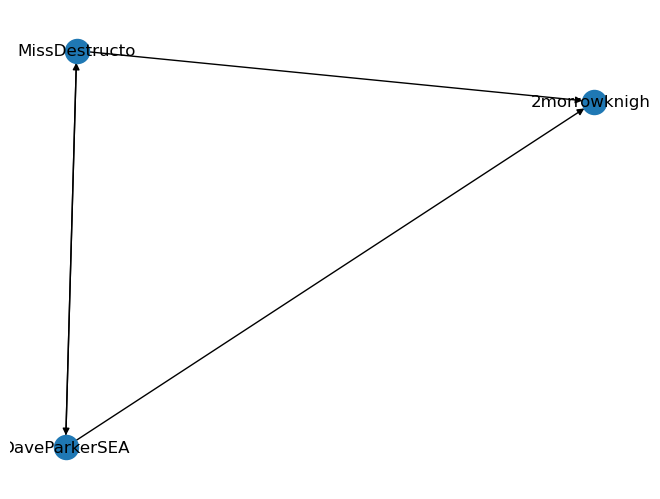

In [17]:
nx.draw(nx.ego_graph(TopFromAdjacency,'2morrowknight',undirected=True),with_labels=True)

Se nota que _2morrowknight_ no tiene flechas que salen (out) de éste. Así, a _2morrowknight_ se le puede alcanzar, pero este no puede alcanzar a otros. Los otros actores los resaltamos aqui:

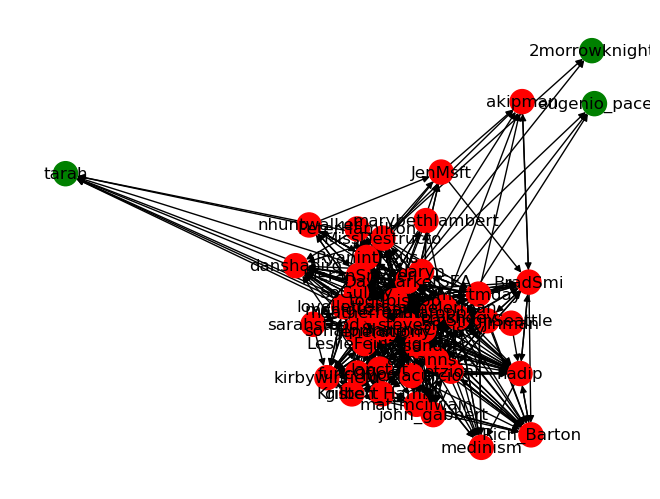

In [18]:
nodesPositions=nx.spring_layout(TopFromAdjacency,k=0.5)
ConnectedComponents =(TopFromAdjacency.subgraph(c).copy() for c in nx.strongly_connected_components(TopFromAdjacency))
color_map = ['red' if node in Seattle_connComp[3] else 'green' for node in TopFromAdjacency.nodes()]
nx.draw(TopFromAdjacency,nodesPositions,node_color=color_map,with_labels=True)

Un concepto que se desprende del _reachability_ es la **reciprocidad**, la proporcion de arcos dirigidos reciprocos, entre todos los arcos dirigidos.

In [19]:
nx.overall_reciprocity(TopFromAdjacency)

0.6632653061224489

La reciprocidad se puede calcular para cada nodo:

In [20]:
pd.DataFrame.from_dict(nx.reciprocity(TopFromAdjacency,nodes=TopFromAdjacency.nodes),
                       orient='index',
                       columns=['reci']).sort_values('reci',ascending=False)

,reci
LeslieFeinzaig,0.941176
john_gabbert,0.923077
ShaunaCausey,0.901961
toddbishop,0.828571
daryn,0.823529
MissDestructo,0.820513
juliesandler,0.807692
rachelerman,0.800000
heatherredman,0.800000
etzioni,0.800000


<div class="alert alert-success" role="alert">Densidad </div>

Finalmente, la **densidad** es otro concepto básico a recordar, nos dice que tan cerca está la red de estar completamente conectada, como podemos notar en la Figura 4.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/density.png" style="width:70%">
<figcaption align = "center"> Figura 4. Densidades en las redes. 
 </figcaption>
 <a href="https://medium.com/@jane.vdplas/https-medium-com-protium-digital-what-are-network-effects-4f1ec159b6">Fuente: Medium</a>
</figure>


La densidad de nuestra red es:

In [21]:
nx.density(TopFromAdjacency)

0.28405797101449276

Hay una relacion muy importante entre density y reachability; son conceptos que NO son sinónimos, como vemos en la Figura 5.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/reachability-and-density.png" style="width:70%">
<figcaption align = "center"> Figura 5. Reachability versus Density. 
 </figcaption>
 <a href="https://www.researchgate.net/publication/42763973_Toward_a_Network_Perspective_of_the_Study_of_Resilience_in_Social-Ecological_Systems">Fuente: Ecology and Society</a>
</figure>


## Explorando a nivel de actor - CENTRALIDAD

Luego de caracterizar a la red, podemos enfocarnos en la relevancia del actor en la red. La relevancia puede entenderse de diferentes maneras, y aqui las más utilizadas:

* Grado o **DEGREE**: Indica la cantidad de conexiones de un nodo, representada en general como un coeficiente, donde 100% (1) indicaría que el nodo se conecta con todos los nodos. Cuando tenemos una red dirigida, se calcula por separado el **IN**DEGREE y el **OUT**DEGREE.
* Cercanía o **CLOSENESS**: Indica que tan cerca está un nodo a todos los demás. Las conexiones de algun nodo le permiten 'llegar' más rápido a los demás que a otros. Es decir, el promedio de sus geodésicos es el menor de todos. Cuando tenemos una red dirigida, se calcula por separado el **IN**CLOSENESS y el **OUT**CLOSENESS.
* Intermediación o **BETWEENNESS**: Indica que tanto es necesario un nodo para que algun nodo llegue a otro nodo. Esta importancia nace también del concepto del geodésico, pues un actor con alto betweenness aparece mucho en los geodésicos de la red,  y en el caso extremo, tiene la capacidad de desconectar a la red.

La Figura 6 ejemplifica estos conceptos.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/centrality.png" style="width:70%">
<figcaption align = "center"> Figura 6. Degree, Closeness y Betweenness. 
 </figcaption>
 <a href="https://www.mdpi.com/2071-1050/14/7/3897">Fuente: Sustainability</a>
</figure>

Aquí podemos ver estas medidas para todos los actores:

In [1]:
actorMeasures=pd.concat([pd.DataFrame.from_dict(nx.out_degree_centrality(TopFromAdjacency),
                                  orient='index',
                                  columns=['OutDegree']),
           pd.DataFrame.from_dict(nx.in_degree_centrality(TopFromAdjacency),
                                  orient='index',
                                  columns=['InDegree']),
           pd.DataFrame.from_dict(nx.closeness_centrality(TopFromAdjacency.reverse()),
                                  orient='index',
                                  columns=['OutCloseness']),
           pd.DataFrame.from_dict(nx.closeness_centrality(TopFromAdjacency),
                                  orient='index',
                                  columns=['InCloseness']),
           pd.DataFrame.from_dict(nx.betweenness_centrality(TopFromAdjacency),
                                  orient='index',
                                  columns=['Betweenness'])],axis=1)
## la tabla de medidas:
actorMeasures

NameError: name 'pd' is not defined

Las Figuras 7 y 8 revelan los actores más relevantes.

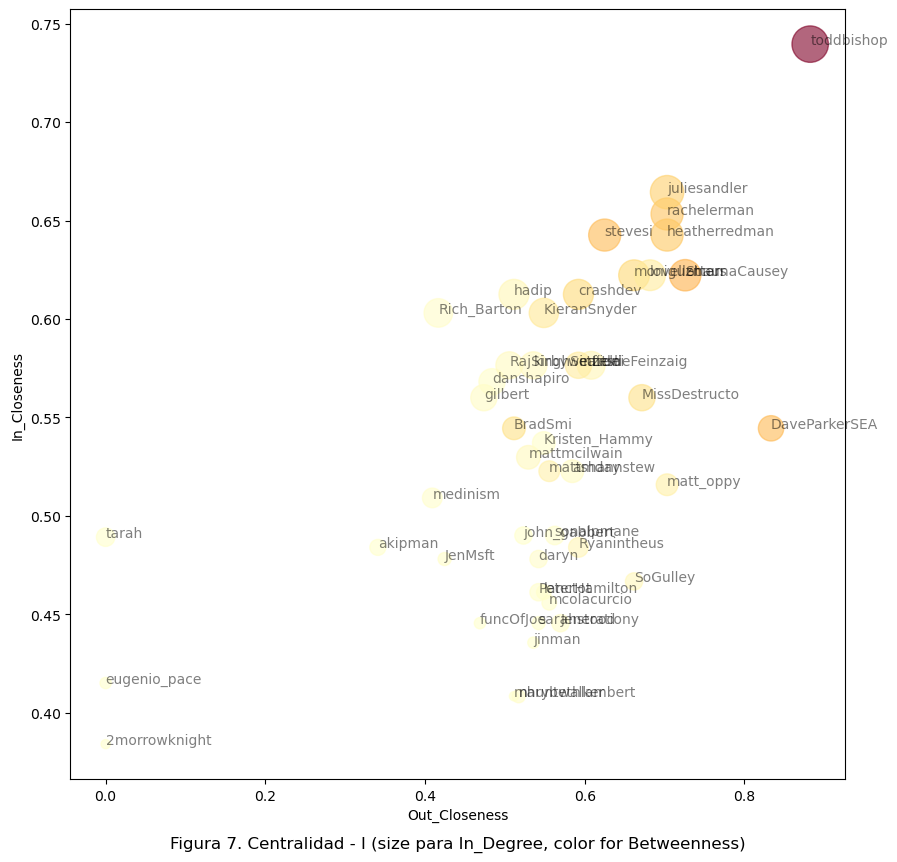

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

ax.scatter(actorMeasures.OutCloseness, actorMeasures.InCloseness,s=1000*actorMeasures.InDegree,
           c=100*actorMeasures.Betweenness,
           cmap=plt.get_cmap('YlOrRd'), alpha=0.6)

valsForAnnotate=zip(actorMeasures.index,actorMeasures.OutCloseness,actorMeasures.InCloseness)
for name,coordX,coordY in valsForAnnotate:
    ax.annotate(name, (coordX,coordY),alpha=0.5)
    
plt.title("Figura 7. Centralidad - I (size para In_Degree, color for Betweenness)", y=-0.1)
plt.xlabel("Out_Closeness")
plt.ylabel("In_Closeness")
plt.show()

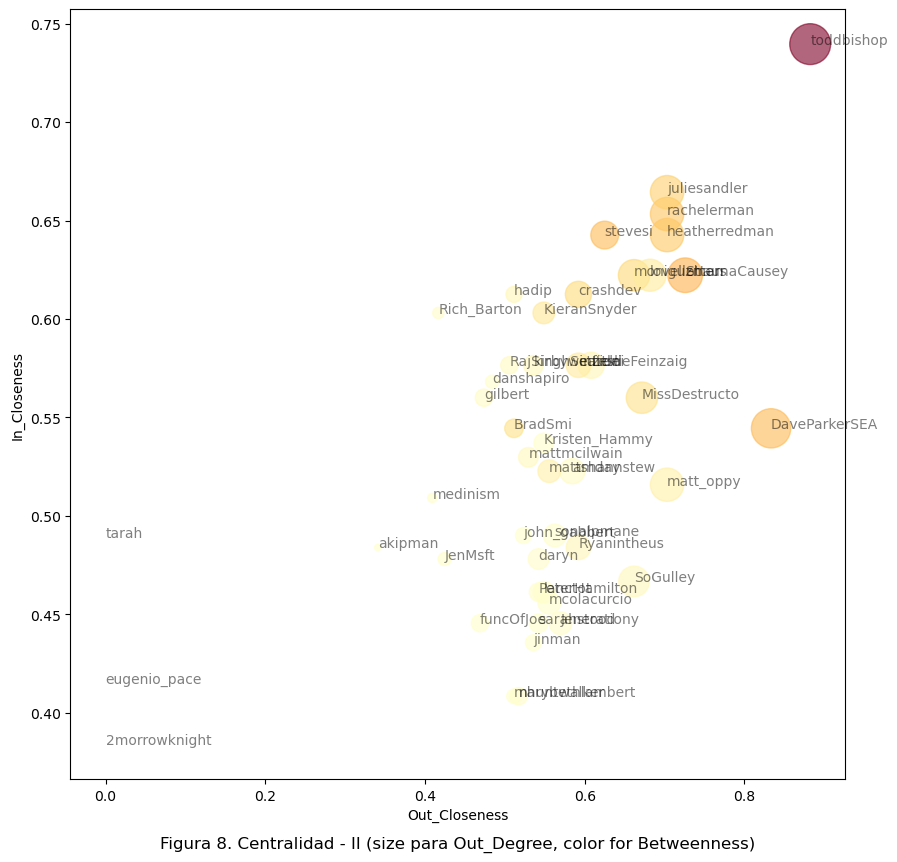

In [24]:
fig, ax = plt.subplots(figsize=(10,10))

ax.scatter(actorMeasures.OutCloseness, actorMeasures.InCloseness,s=1000*actorMeasures.OutDegree,
           c=100*actorMeasures.Betweenness,
           cmap=plt.get_cmap('YlOrRd'), alpha=0.6)

valsForAnnotate=zip(actorMeasures.index,actorMeasures.OutCloseness,actorMeasures.InCloseness)
for name,coordX,coordY in valsForAnnotate:
    ax.annotate(name, (coordX,coordY),alpha=0.5)
    
plt.title("Figura 8. Centralidad - II (size para Out_Degree, color for Betweenness)", y=-0.1)
plt.xlabel("Out_Closeness")
plt.ylabel("In_Closeness")
plt.show()